In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data=fetch_california_housing(as_frame=True)
df=pd.concat([data.data,data.target.rename("HousePrice")],axis=1)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
X=df.drop("HousePrice",axis=1)
Y=df["HousePrice"]
print("Features Shape:",X.shape)
print("Target Shape:",Y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


In [6]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
print("Feature Scaling Completed")
print(X_scaled.shape)

Feature Scaling Completed
(20640, 8)


In [7]:
X_train,X_test,Y_train,Y_test=train_test_split(X_scaled,Y,test_size=0.2,random_state=42)
print("Training Shape:",X_train.shape)
print("Testing Shape:",X_test.shape)

Training Shape: (16512, 8)
Testing Shape: (4128, 8)


In [8]:
models={"Linear Regression":LinearRegression(),"Ridge Regression":Ridge(alpha=1.0),"Decision Tree":DecisionTreeRegressor(max_depth=5)}
print("Models Created Successfully")
        

Models Created Successfully


In [9]:
results={}
for name,model in models.items():
    model.fit(X_train,Y_train)
    predictions=model.predict(X_test)
    rmse=np.sqrt(mean_squared_error(Y_test,predictions))
    r2=r2_score(Y_test,predictions)
    results[name]={"RMSE":rmse,"R2Score":r2}
results_df=pd.DataFrame(results).T
results_df

,RMSE,R2Score
Linear Regression,0.745581,0.575788
Ridge Regression,0.745554,0.575819
Decision Tree,0.724234,0.599732


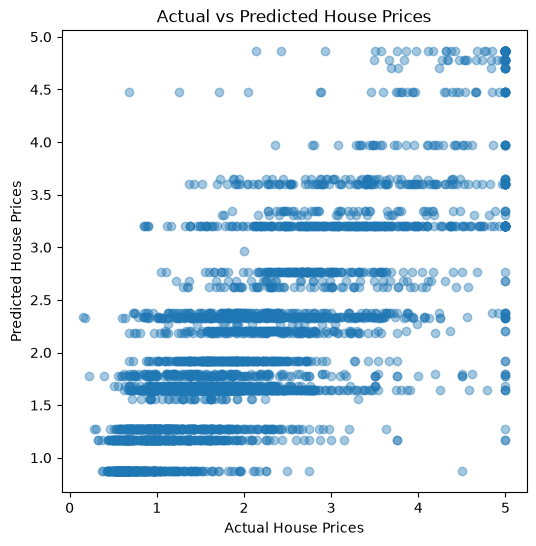

In [12]:
best_model = DecisionTreeRegressor(max_depth=5)

best_model.fit(X_train, Y_train)

Y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(Y_test, Y_pred, alpha=0.4)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()